In [ ]:
import io
import pandas as pd
import lightgbm as lgb
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from pandas import DataFrame
from numpy import argmax

In [ ]:
df = pd.read_csv("test - Sheet1.csv",header=0)
df.head()

,STATION,WQI,YEAR,WQICLS
0,9967,113.7,2019,4
1,7589,114.0,2019,4
2,2694,115.0,2019,4
3,9967,18.0,2019,0
4,4356,19.0,2019,0


In [ ]:
df.dtypes

STATION      int64
WQI        float64
YEAR         int64
WQICLS       int64
dtype: object

In [ ]:
df ['STATION']=df.STATION.astype(object)

In [ ]:
df['WQICLS'].value_counts()

1    38
0    36
4    34
2    26
3    25
Name: WQICLS, dtype: int64

In [ ]:
x =df[['WQI ']]
y =df['WQICLS']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.38)

In [ ]:
params = {                #hyperparameters
    'boosting': 'gbdt',         #baselearner
    'objective': 'multiclass',
    'num_leaves': 10,
    'num_class': 5
}

In [ ]:
lgb_train = lgb.Dataset(x_train, y_train)
lgb_eval = lgb.Dataset(x_test, y_test, reference=lgb_train)

In [ ]:
model = lgb.train(params,
                 train_set=lgb_train,
                 valid_sets=lgb_eval,
                 early_stopping_rounds=30)

/usr/local/lib/python3.10/dist-packages/lightgbm/engine.py:181: UserWarning: 'early_stopping_rounds' argument is deprecated and will be removed in a future release of LightGBM. Pass 'early_stopping()' callback via 'callbacks' argument instead.
  _log_warning("'early_stopping_rounds' argument is deprecated and will be removed in a future release of LightGBM. "


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002637 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 33
[LightGBM] [Info] Number of data points in the train set: 98, number of used features: 1
[LightGBM] [Info] Start training from score -1.540445
[LightGBM] [Info] Start training from score -1.406914
[LightGBM] [Info] Start training from score -1.876917
[LightGBM] [Info] Start training from score -1.876917
[LightGBM] [Info] Start training from score -1.449473
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

In [ ]:
y_pred = model.predict(x_test)

y_pred = argmax(y_pred, axis=1)
cr = classification_report(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(cr)
print(cm)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00        14
           2       0.92      1.00      0.96        11
           3       0.90      0.90      0.90        10
           4       1.00      0.91      0.95        11

    accuracy                           0.97        61
   macro avg       0.96      0.96      0.96        61
weighted avg       0.97      0.97      0.97        61

[[15  0  0  0  0]
 [ 0 14  0  0  0]
 [ 0  0 11  0  0]
 [ 0  0  1  9  0]
 [ 0  0  0  1 10]]


<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

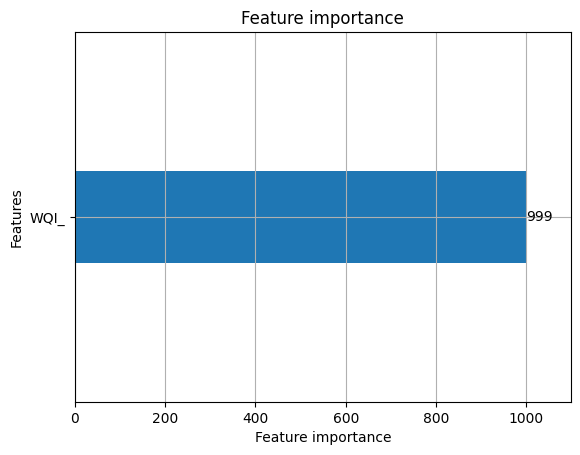

In [ ]:
lgb.plot_importance(model, height=.5)


In [ ]:
model.save_model('lgbmmodel.model')

In [ ]:
filepath= '/content/lgbmmodel.model'
loaded_model = lgb.Booster(model_file=filepath)

In [ ]:
new_data1 = pd.read_csv('/content/new.csv')

In [ ]:
relevant_data = new_data1[['WQI']]

In [ ]:
predictions1 = loaded_model.predict(relevant_data)

In [ ]:
labels1 = np.argmax(predictions1, axis=1)

In [ ]:
print(labels1)

[2 1 4 2 3 4 2 2]


In [ ]:
new_data1['wqicls']=labels1

In [ ]:
new_data1.to_csv('new_data_with_predictions.csv', index=False)